# Spotify Tracks Project #

### INFORMATION ABOUT THE DATASET ###

**About Dataset**
**Content**

This is a dataset of Spotify tracks over a range of 125 different genres. Each track has some audio features associated with it. The data is in CSV format which is tabular and can be loaded quickly.

**Usage**

The dataset can be used for:

- Building a Recommendation System based on some user input or preference
- Classification purposes based on audio features and available genres
- Any other application that you can think of. Feel free to discuss!
- Column Description

**track_id**: The Spotify ID for the track

**artists**: The artists' names who performed the track. If there is more than one artist, they are separated by a ;

**album_name**: The album name in which the track appears

**track_name**: Name of the track

**popularity**: The popularity of a track is a value between 0 and 100, with 100 being the most popular. The popularity is calculated by algorithm and is based, in the most part, on the total number of plays the track has had and how recent those plays are. Generally speaking, songs that are being played a lot now will have a higher popularity than songs that were played a lot in the past. Duplicate tracks (e.g. the same track from a single and an album) are rated independently. Artist and album popularity is derived mathematically from track popularity.

**duration_ms**: The track length in milliseconds

**explicit**: Whether or not the track has explicit lyrics (true = yes it does; false = no it does not OR unknown)

**danceability**: Danceability describes how suitable a track is for dancing based on a combination of musical elements including tempo, rhythm stability, beat strength, and overall regularity. A value of 0.0 is least danceable and 1.0 is most danceable

**energy**: Energy is a measure from 0.0 to 1.0 and represents a perceptual measure of intensity and activity. Typically, energetic tracks feel fast, loud, and noisy. For example, death metal has high energy, while a Bach prelude scores low on the scale

**key**: The key the track is in. Integers map to pitches using standard Pitch Class notation. E.g. 0 = C, 1 = C♯/D♭, 2 = D, and so on. If no key was detected, the value is -1

**loudness**: The overall loudness of a track in decibels (dB)

**mode**: Mode indicates the modality (major or minor) of a track, the type of scale from which its melodic content is derived. Major is represented by 1 and minor is 0

**speechiness**: Speechiness detects the presence of spoken words in a track. The more exclusively speech-like the recording (e.g. talk show, audio book, poetry), the closer to 1.0 the attribute value. Values above 0.66 describe tracks that are probably made entirely of spoken words. Values between 0.33 and 0.66 describe tracks that may contain both music and speech, either in sections or layered, including such cases as rap music. Values below 0.33 most likely represent music and other non-speech-like tracks

**acousticness**: A confidence measure from 0.0 to 1.0 of whether the track is acoustic. 1.0 represents high confidence the track is acoustic

**instrumentalness**: Predicts whether a track contains no vocals. "Ooh" and "aah" sounds are treated as instrumental in this context. Rap or spoken word tracks are clearly "vocal". The closer the instrumentalness value is to 1.0, the greater likelihood the track contains no vocal content

**liveness**: Detects the presence of an audience in the recording. Higher liveness values represent an increased probability that the track was performed live. A value above 0.8 provides strong likelihood that the track is live

**valence**: A measure from 0.0 to 1.0 describing the musical positiveness conveyed by a track. Tracks with high valence sound more positive (e.g. happy, cheerful, euphoric), while tracks with low valence sound more negative (e.g. sad, depressed, angry)

**tempo**: The overall estimated tempo of a track in beats per minute (BPM). In musical terminology, tempo is the speed or pace of a given piece and derives directly from the average beat duration

**time_signature**: An estimated time signature. The time signature (meter) is a notational convention to specify how many beats are in each bar (or measure). The time signature ranges from 3 to 7 indicating time signatures of 3/4, to 7/4.

**track_genre**: The genre in which the track belongs

**Step 1:** Importing all the necessary libraries.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import umap

**Step 2**: Importing the dataset to a dataframe.

In [291]:
df_spotify = pd.read_csv("dataset.csv")
df_spotify.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


**Step 3**: Drop the unnamed column.

In [292]:
df_spotify.columns

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='object')

In [293]:
df_spotify.drop("Unnamed: 0", axis = 1, inplace = True)
df_spotify.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [294]:
df_spotify.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           11

In [295]:
df_spotify[df_spotify['artists'].isna()]

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
65900,1kR4gIb7nGxHPI3D2ifs59,NaN,NaN,NaN,0,0,False,0.501,0.583,7,-9.46,0,0.0605,0.69,0.00396,0.0747,0.734,138.391,4,k-pop


In [296]:
df_spotify.drop(65900, axis = 0, inplace = True)
df_spotify.reset_index(inplace = True)

In [297]:
df_spotify.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113999 entries, 0 to 113998
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   index             113999 non-null  int64  
 1   track_id          113999 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        113999 non-null  int64  
 6   duration_ms       113999 non-null  int64  
 7   explicit          113999 non-null  bool   
 8   danceability      113999 non-null  float64
 9   energy            113999 non-null  float64
 10  key               113999 non-null  int64  
 11  loudness          113999 non-null  float64
 12  mode              113999 non-null  int64  
 13  speechiness       113999 non-null  float64
 14  acousticness      113999 non-null  float64
 15  instrumentalness  113999 non-null  float64
 16  liveness          11

In [298]:
df_spotify[df_spotify.duplicated()]

,index,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre


In [299]:
df_spotify.describe()

,index,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,113999.000000,113999.000000,1.139990e+05,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000
mean,56999.421925,33.238827,2.280312e+05,0.566801,0.641383,5.309126,-8.258950,0.637558,0.084652,0.314907,0.156051,0.213554,0.474066,122.147695,3.904034
std,32909.243463,22.304959,1.072961e+05,0.173543,0.251530,3.559999,5.029357,0.480708,0.105733,0.332522,0.309556,0.190378,0.259261,29.978290,0.432623
min,0.000000,0.000000,8.586000e+03,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.500000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218500,4.000000
50%,56999.000000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.500000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.597500,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [300]:
num_features = df_spotify.select_dtypes(include = ['number'])

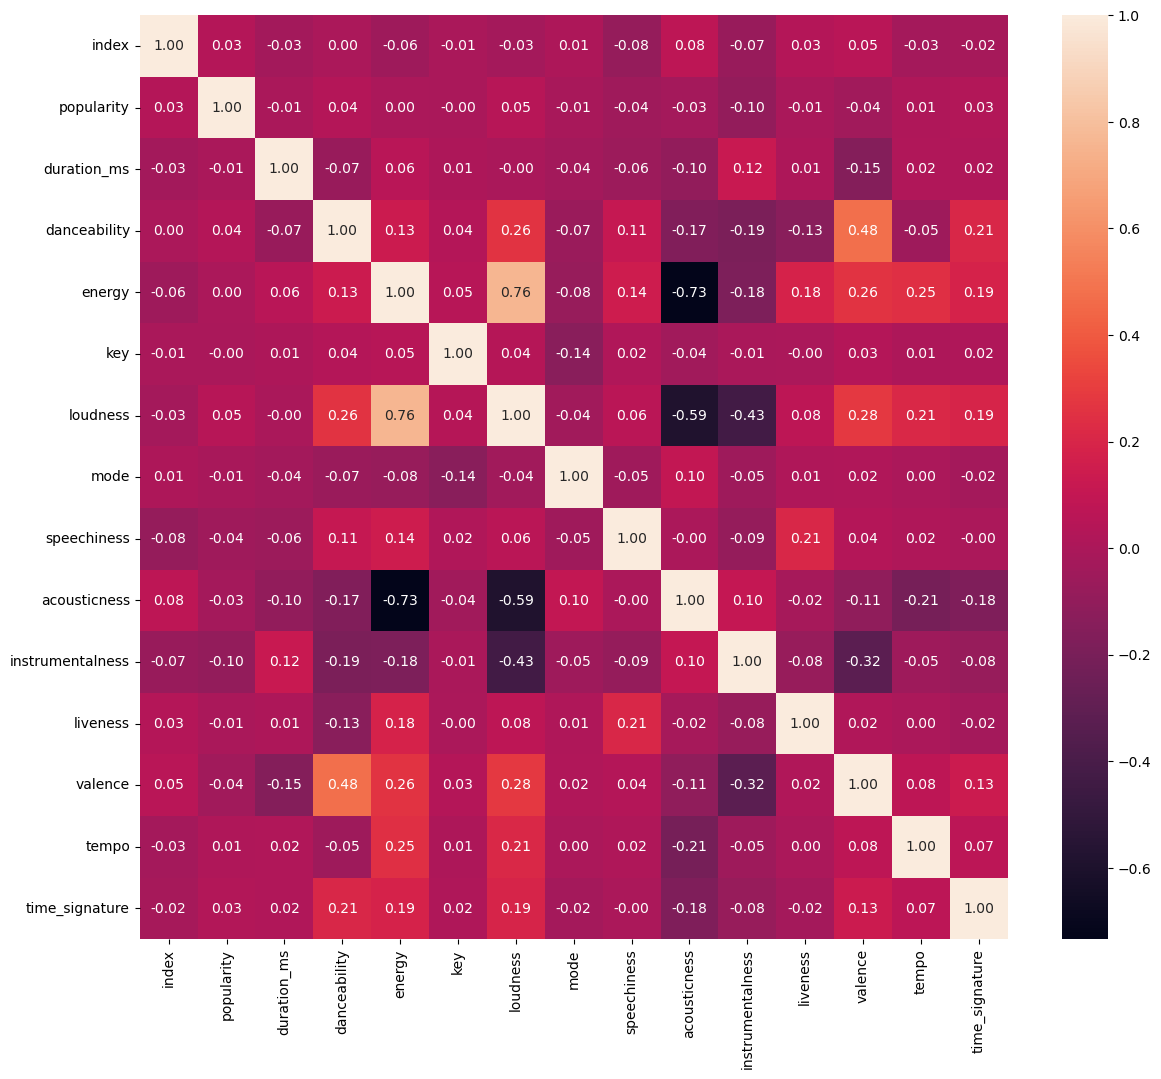

In [301]:
fig = plt.figure(figsize = (14,12))
corr = num_features.corr()
sns.heatmap(corr, annot = True, fmt = '.2f')
plt.show()

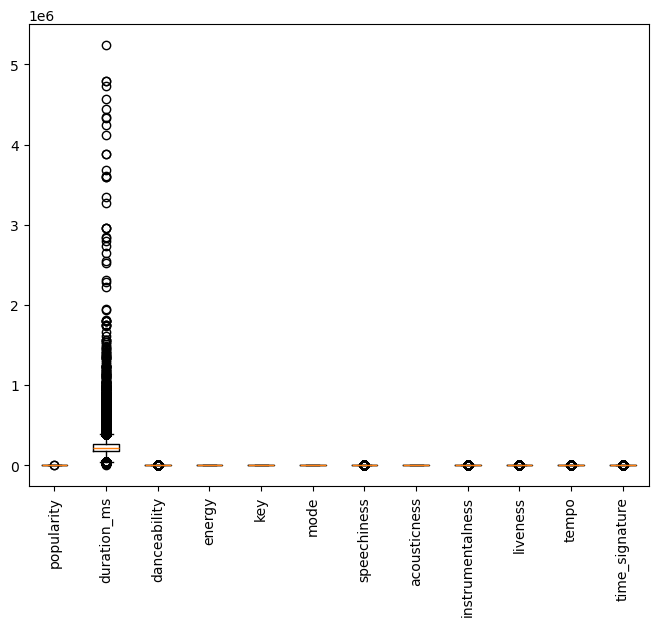

In [302]:
spotify_clustering = num_features.drop(columns=['index', 'loudness', 'valence'])

plt.figure(figsize=(8, 6))
plt.boxplot(spotify_clustering)

plt.xticks(
    ticks=range(1, len(spotify_clustering.columns) + 1),
    labels=spotify_clustering.columns,
    rotation=90
)

plt.show()

In [303]:
spotify_clustering['time_signature'].value_counts()

time_signature
4    101842
3      9195
5      1826
1       973
0       163
Name: count, dtype: int64

In [304]:
spotify_clustering['log_duration_ms'] = np.log(spotify_clustering['duration_ms'])
spotify_clustering['log_speechiness'] = np.log1p(spotify_clustering['speechiness'])

In [305]:
# from sklearn.preprocessing import PowerTransformer
# pt = PowerTransformer(method='yeo-johnson')
# spotify_clustering['loudness_transformed'] = pt.fit_transform(spotify_clustering[['loudness']])

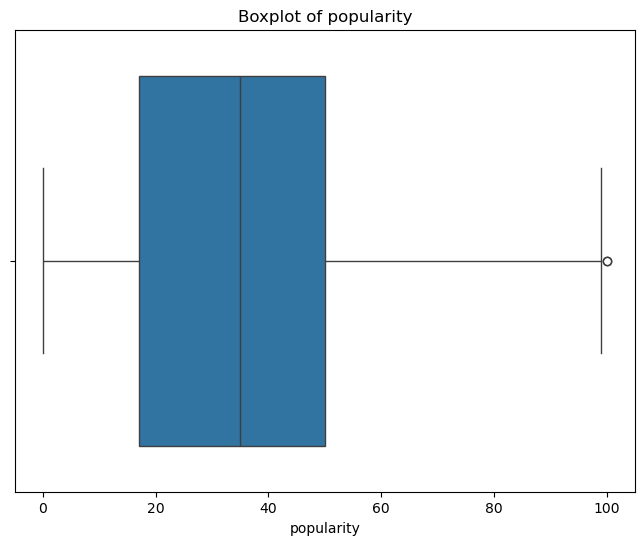

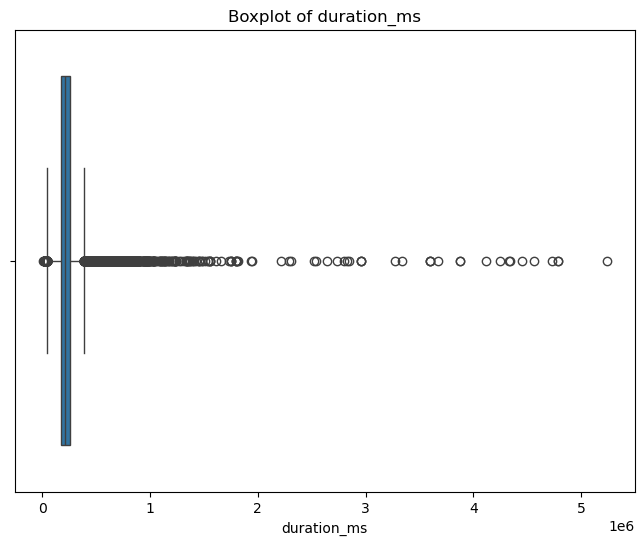

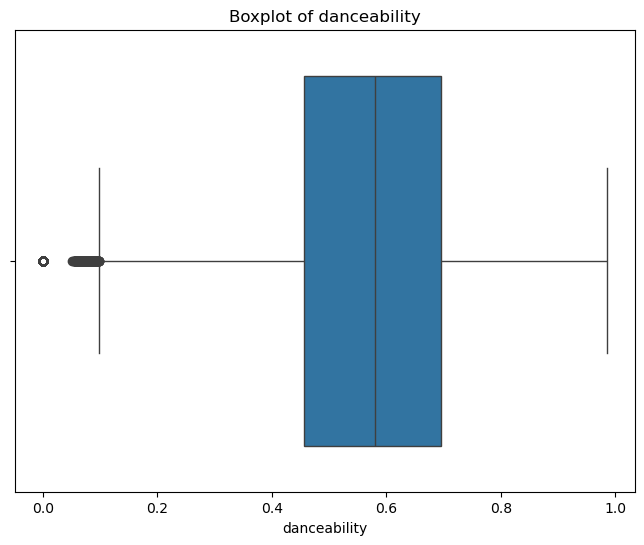

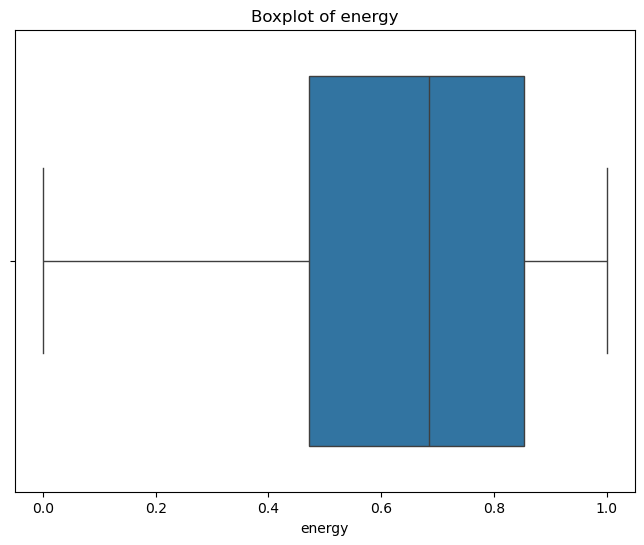

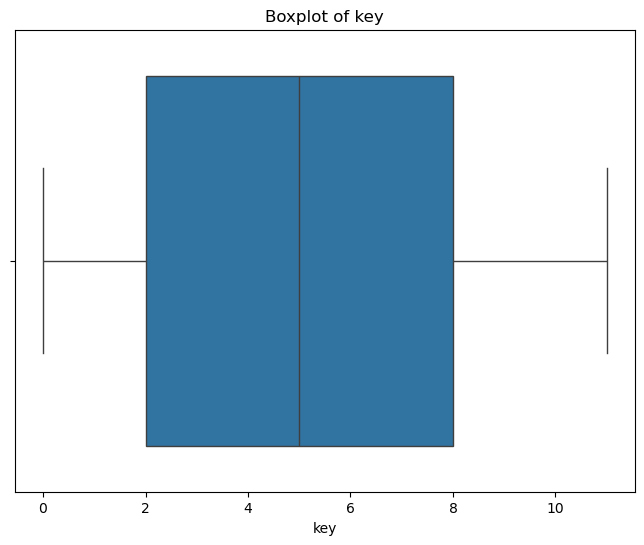

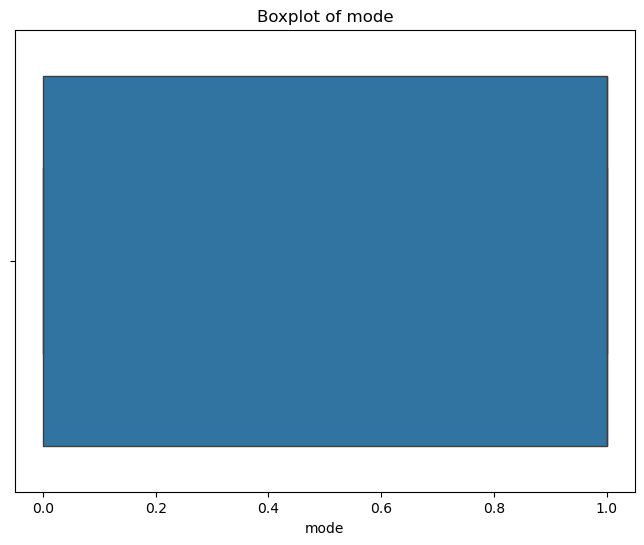

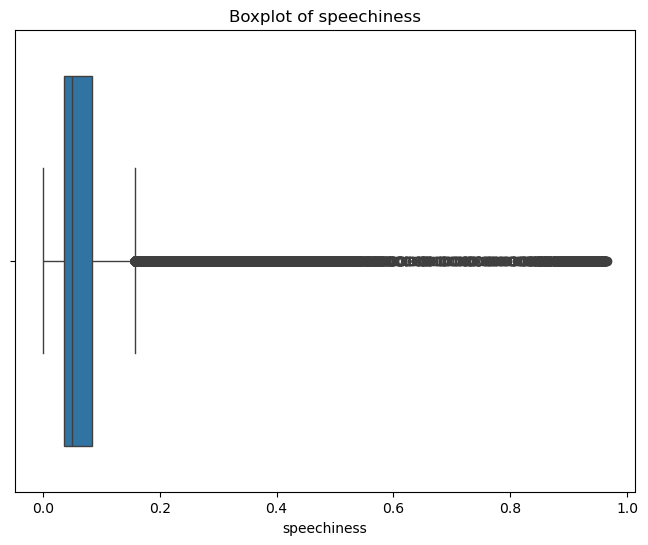

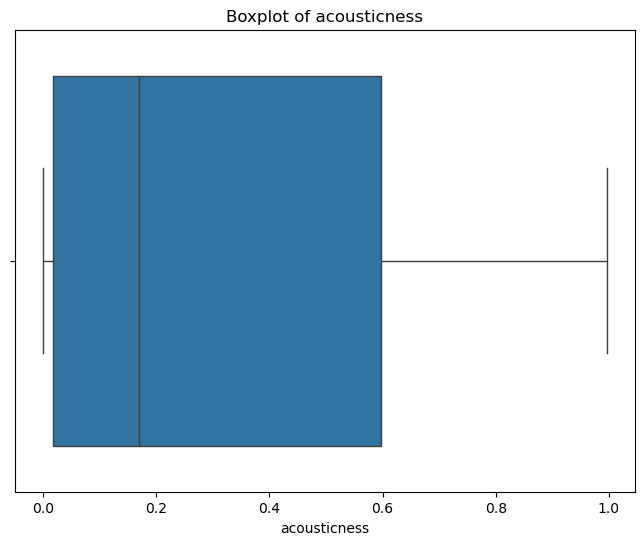

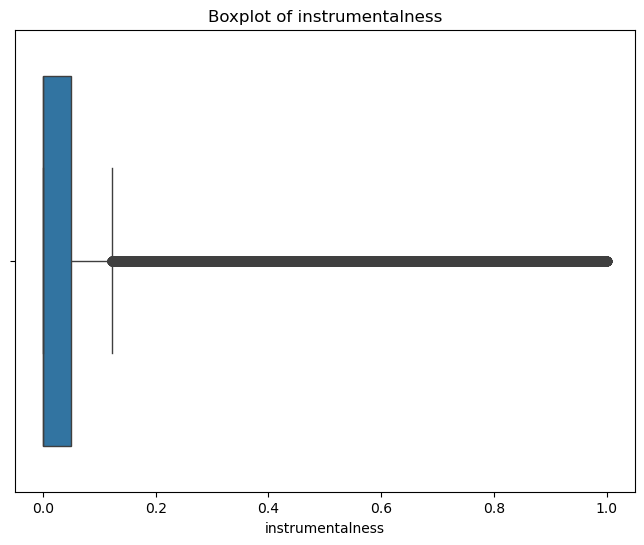

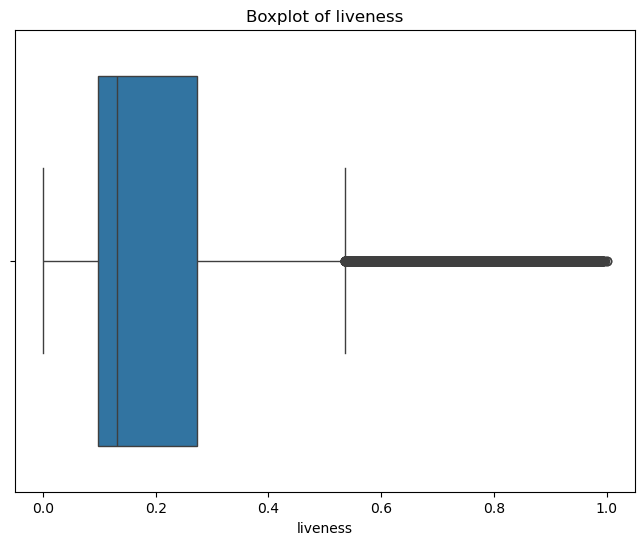

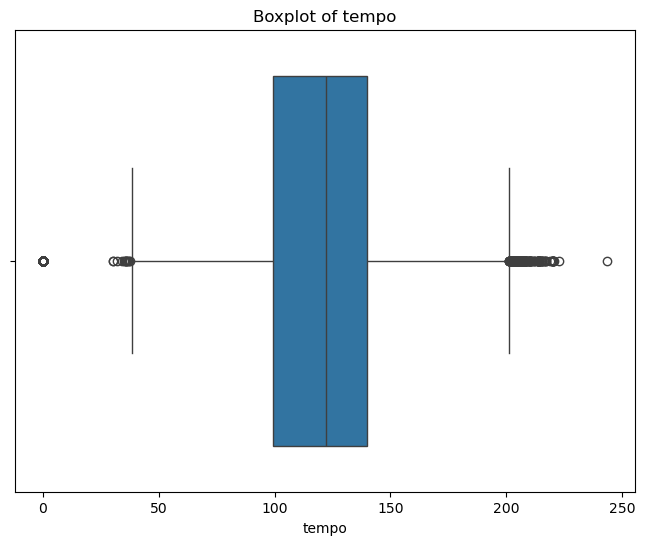

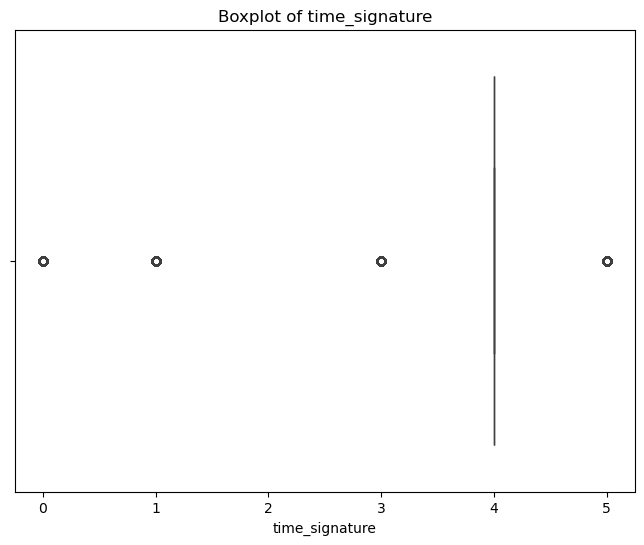

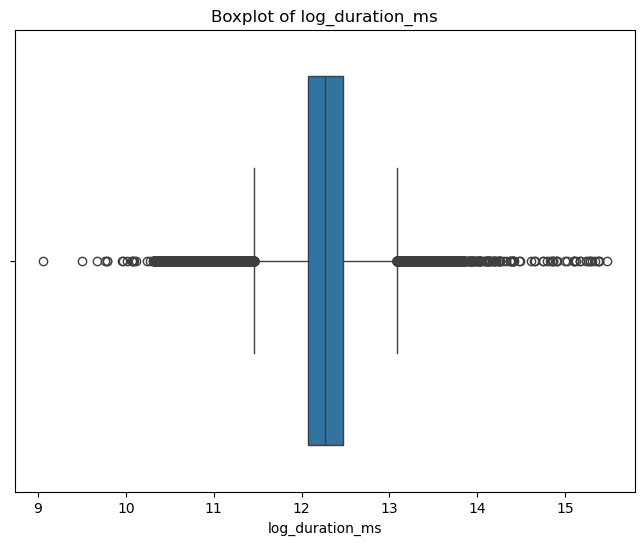

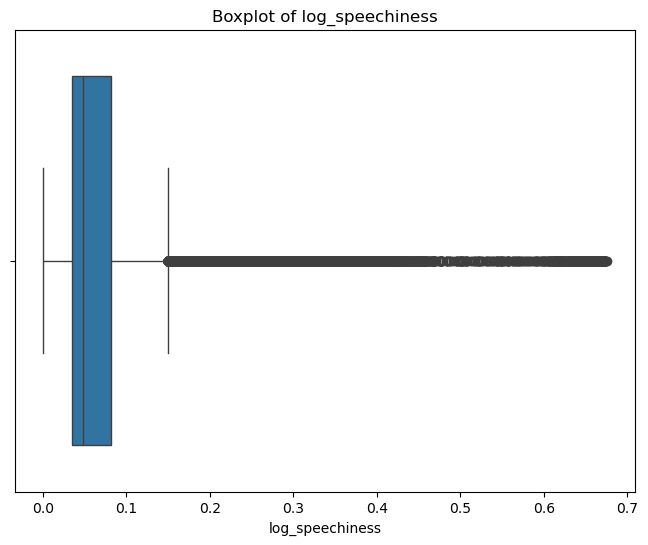

In [306]:
for variable in spotify_clustering.columns:
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=spotify_clustering, x=variable)
    plt.title(f'Boxplot of {variable}')
    plt.show()

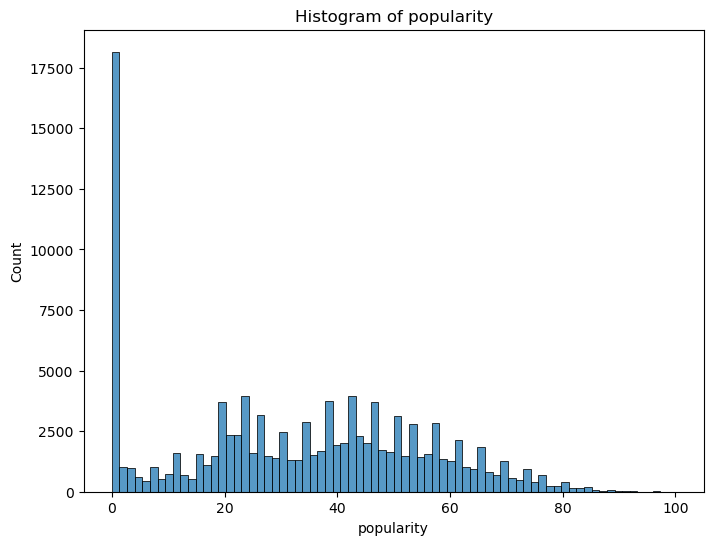

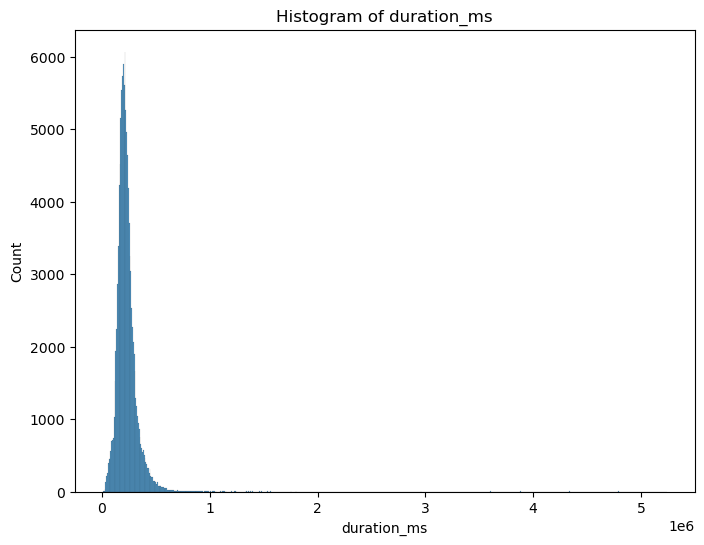

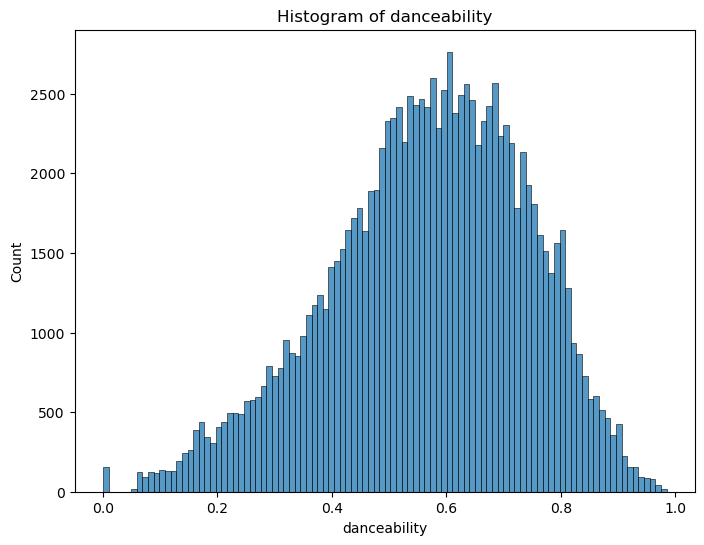

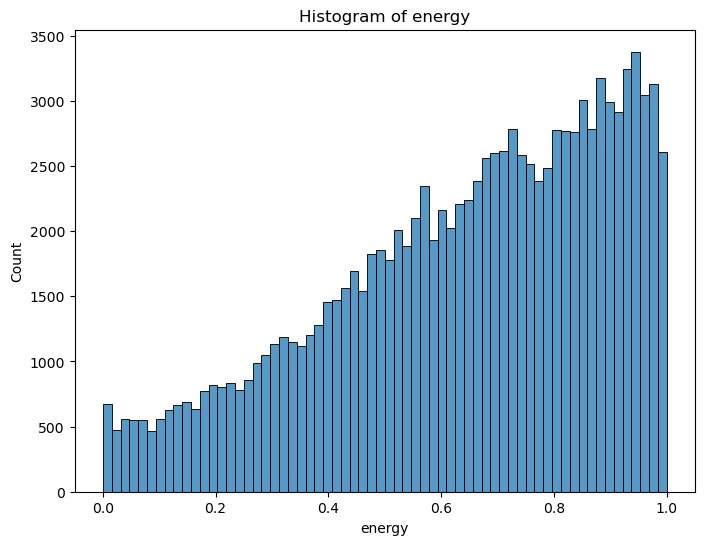

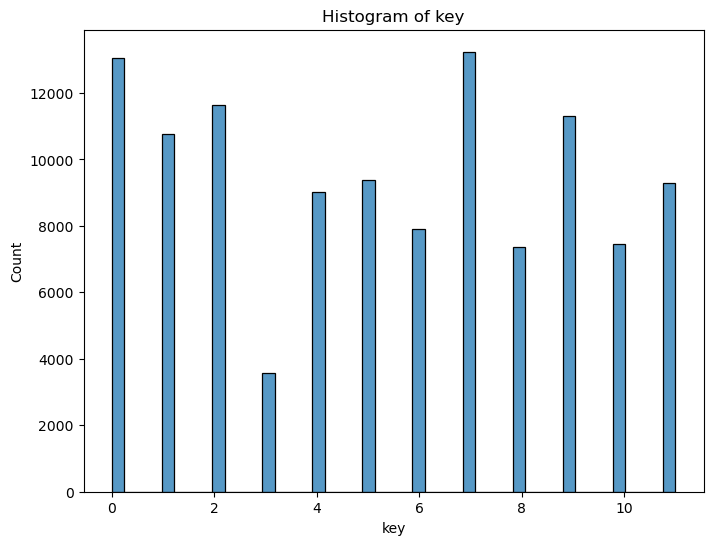

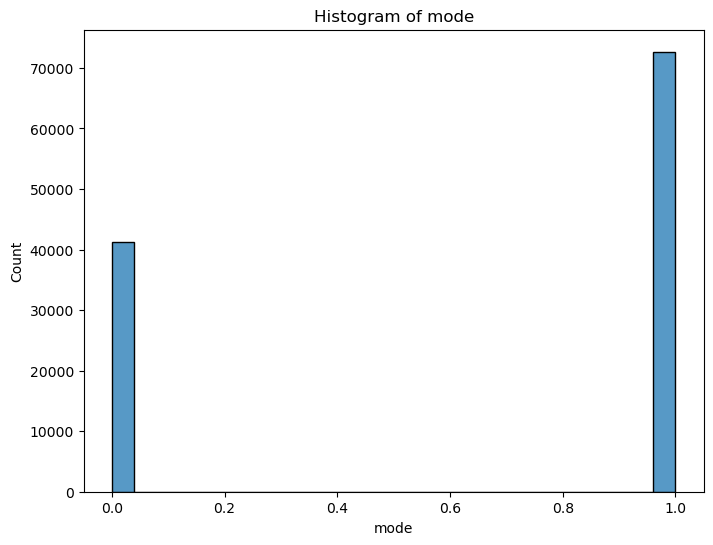

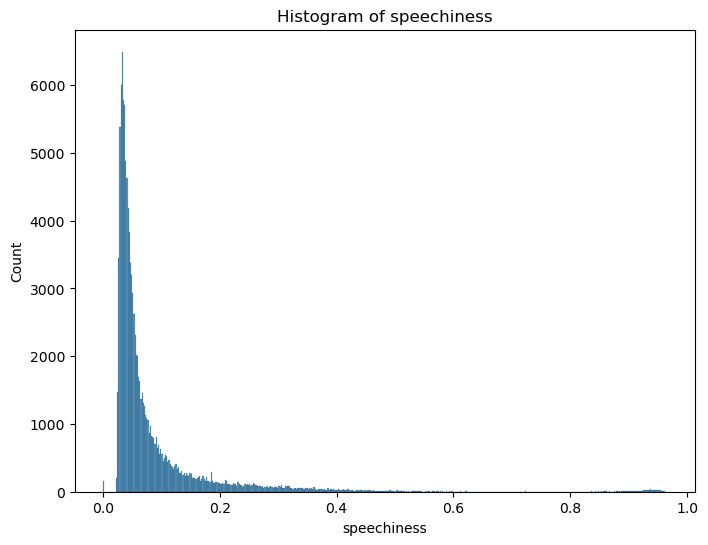

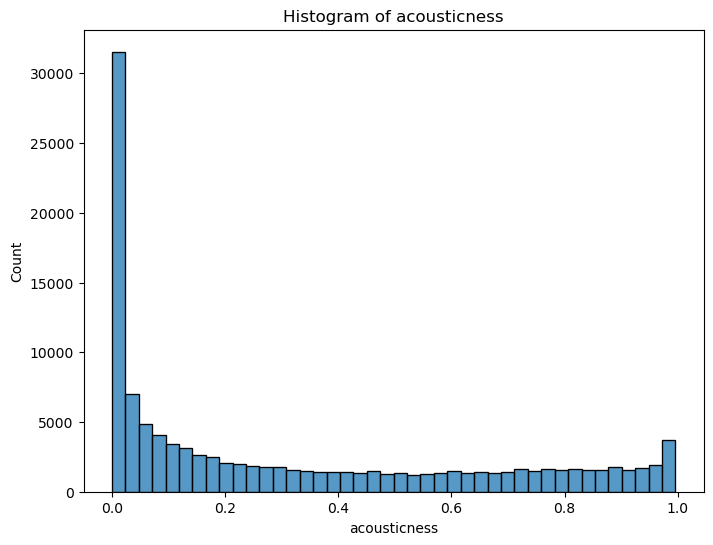

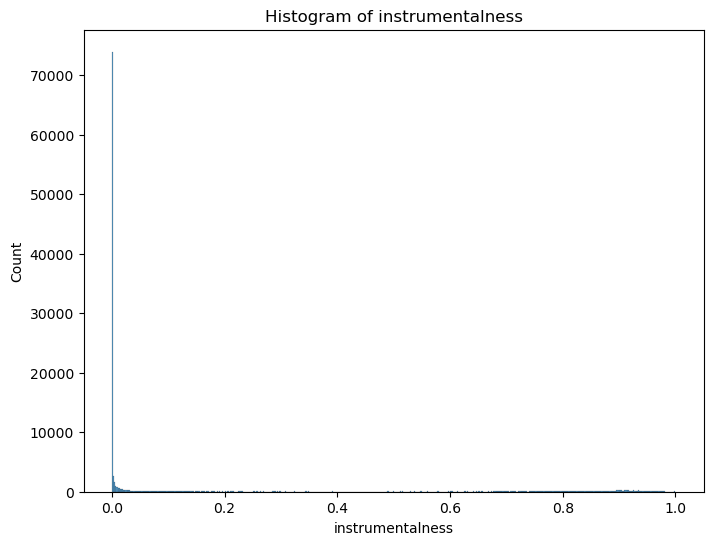

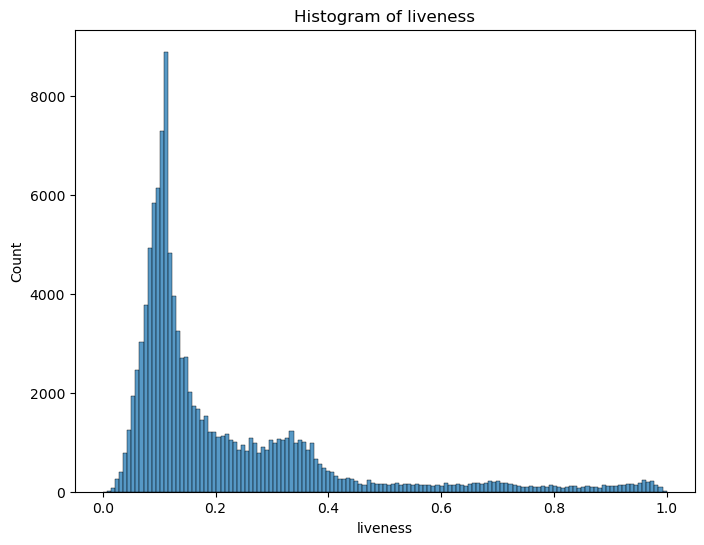

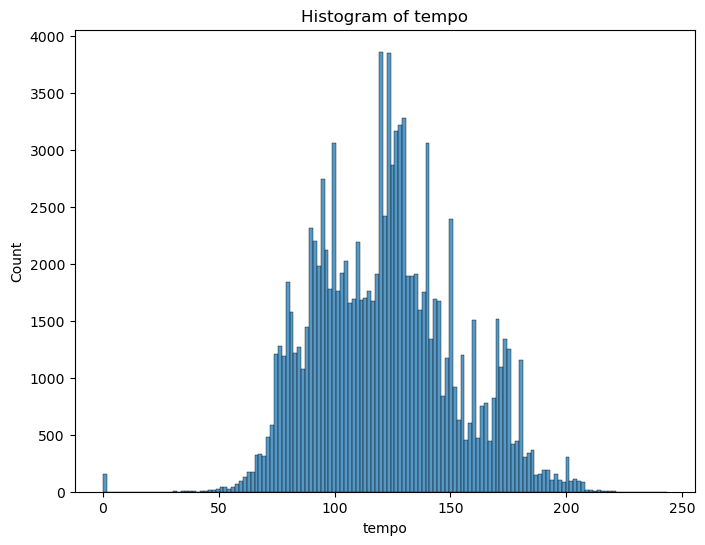

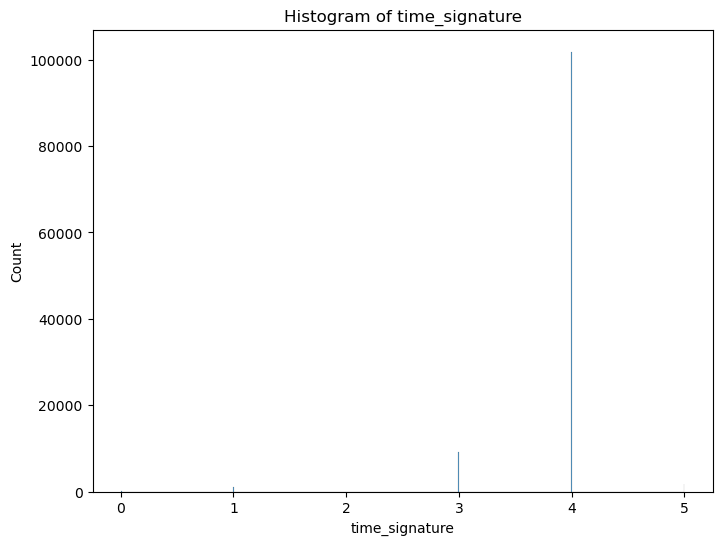

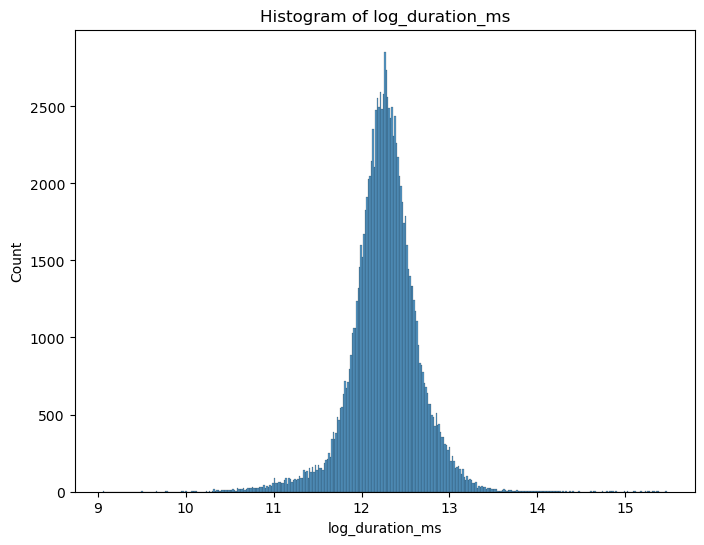

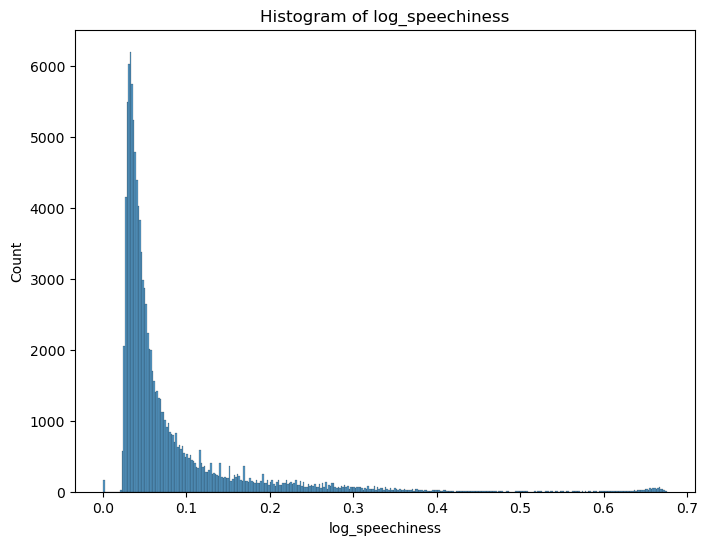

In [307]:
for variable in spotify_clustering.columns:
    plt.figure(figsize=(8, 6))
    sns.histplot(data=spotify_clustering, x=variable)
    plt.title(f'Histogram of {variable}')
    plt.show()

- drop mode, since it is a dummy variable

In [308]:
spotify_clustering.drop(columns=['mode'], inplace=True)

In [309]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
spotify_clustering_scaled = scaler.fit_transform(spotify_clustering)

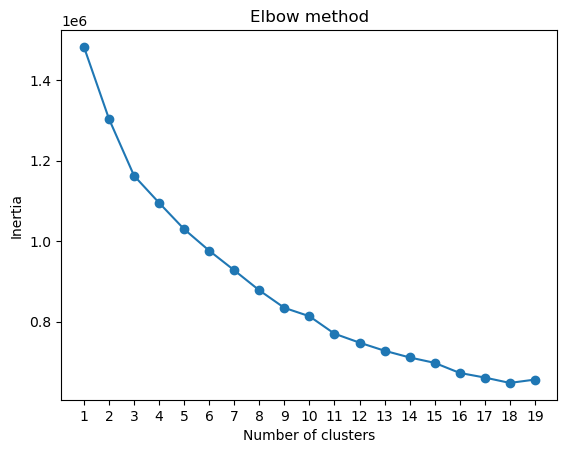

In [310]:
from sklearn.cluster import KMeans

inertias = []

for i in range(1,20):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(spotify_clustering_scaled)
    inertias.append(kmeans.inertia_)

plt.plot(range(1,20), inertias, marker='o')
plt.title('Elbow method')
plt.xticks(range(1,20))
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

K-means

In [311]:
kmeans = KMeans(n_clusters=10, random_state=0).fit(spotify_clustering_scaled)
spotify_clustering['cluster_kmeans'] = kmeans.predict(spotify_clustering_scaled)

In [312]:
spotify_clustering

,popularity,duration_ms,danceability,energy,key,speechiness,acousticness,instrumentalness,liveness,tempo,time_signature,log_duration_ms,log_speechiness,cluster_kmeans
0,73,230666,0.676,0.4610,1,0.1430,0.0322,0.000001,0.3580,87.917,4,12.348726,0.133656,9
1,55,149610,0.420,0.1660,1,0.0763,0.9240,0.000006,0.1010,77.489,4,11.915787,0.073529,7
2,57,210826,0.438,0.3590,0,0.0557,0.2100,0.000000,0.1170,76.332,4,12.258788,0.054204,9
3,71,201933,0.266,0.0596,0,0.0363,0.9050,0.000071,0.1320,181.740,3,12.215691,0.035657,2
4,82,198853,0.618,0.4430,2,0.0526,0.4690,0.000000,0.0829,119.949,4,12.200321,0.051263,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113994,21,384999,0.172,0.2350,5,0.0422,0.6400,0.928000,0.0863,125.995,5,12.860996,0.041334,4
113995,22,385000,0.174,0.1170,0,0.0401,0.9940,0.976000,0.1050,85.239,4,12.860999,0.039317,4
113996,22,271466,0.629,0.3290,0,0.0420,0.8670,0.000000,0.0839,132.378,4,12.511592,0.041142,7
113997,41,283893,0.587,0.5060,7,0.0297,0.3810,0.000000,0.2700,135.960,4,12.556353,0.029267,5


In [314]:
spotify_clustering.groupby('cluster_kmeans').mean()

,popularity,duration_ms,danceability,energy,key,speechiness,acousticness,instrumentalness,liveness,tempo,time_signature,log_duration_ms,log_speechiness
cluster_kmeans,,,,,,,,,,,,,
0,30.434892,216347.039561,0.426765,0.859374,5.697001,0.095149,0.074101,0.129246,0.211626,158.568673,3.941148,12.235605,0.089384
1,32.236028,198418.059866,0.655482,0.672453,5.426479,0.446580,0.370209,0.033552,0.299695,119.726282,3.937240,12.109896,0.359632
2,29.053869,206560.775224,0.439015,0.362010,4.954027,0.048948,0.662947,0.101822,0.184283,116.433065,2.598000,12.160661,0.047048
3,6.059724,201132.573275,0.682359,0.745013,5.605019,0.076644,0.147372,0.049010,0.169463,115.965127,3.995671,12.175873,0.072640
4,30.542539,184018.936661,0.418970,0.239283,4.921632,0.052850,0.800274,0.862936,0.143670,108.128053,3.839640,12.016025,0.051004
5,51.871245,219733.401652,0.647043,0.710086,8.524863,0.065397,0.186881,0.046169,0.165238,116.782513,3.989365,12.269292,0.062420
6,25.655224,421123.741618,0.583265,0.707922,5.570431,0.063225,0.127740,0.625898,0.166674,125.502070,3.955372,12.886443,0.060578
7,31.377172,204515.195234,0.533917,0.362921,4.967680,0.046673,0.748725,0.019348,0.160880,111.517093,4.029818,12.175432,0.045207
8,36.076867,237887.742555,0.512404,0.752574,5.269327,0.075649,0.292123,0.084252,0.760850,122.686424,3.964941,12.321412,0.071698


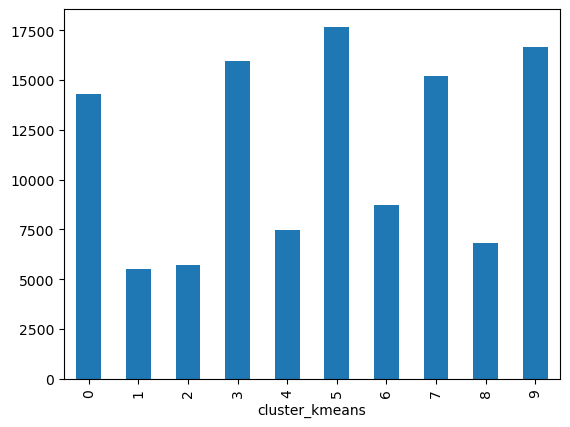

In [313]:
spotify_clustering.groupby('cluster_kmeans').size().plot(kind='bar')
plt.show()

Cluster 5 is the cluster with most songs.

### UMAP - Dimensionality Reduction

In [9]:
import umap

# Apply UMAP with 2 components for visualization
umap_reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
umap_embeddings = umap_reducer.fit_transform(spotify_clustering_scaled)

/opt/anaconda3/envs/machine_learning/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/anaconda3/envs/machine_learning/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/machine_learning/lib/python3.13/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/opt/anaconda3/envs/machine_learning/lib/python3.13/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some

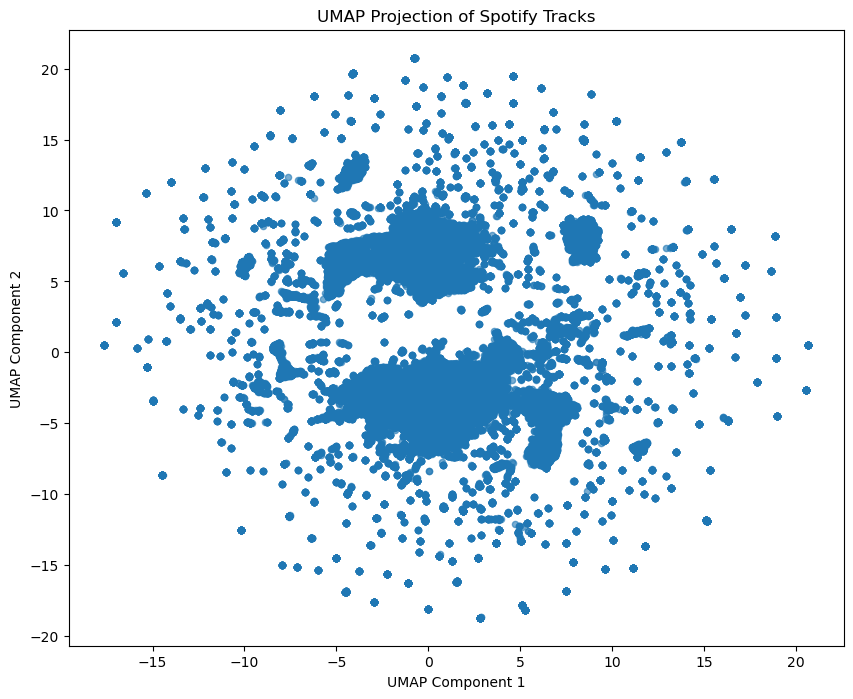

In [14]:
plt.figure(figsize=(10, 8))
plt.scatter(umap_embeddings[:, 0], umap_embeddings[:, 1], alpha=0.6, s=20)
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.title('UMAP Projection of Spotify Tracks')
plt.show()

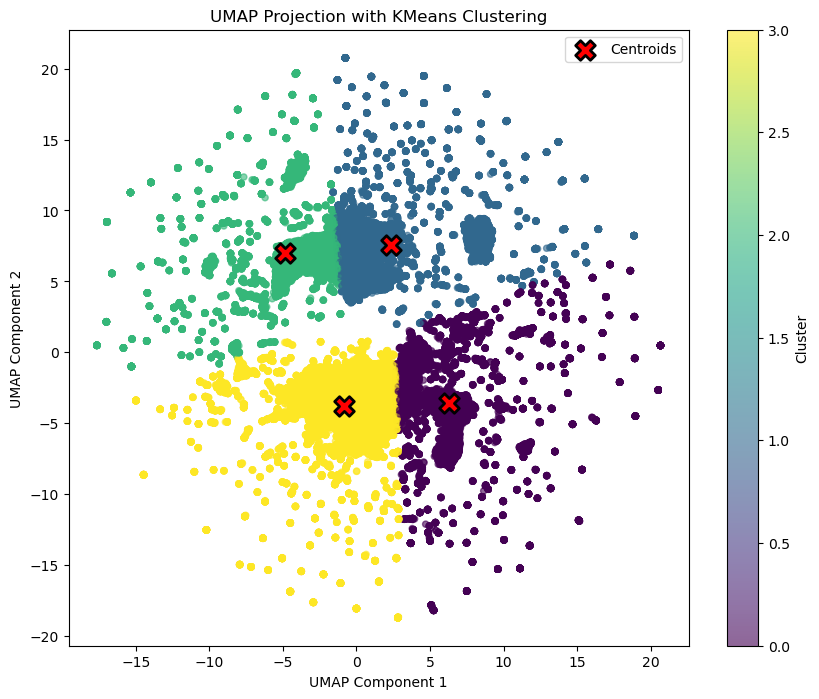

In [ ]:
# Apply KMeans clustering on UMAP embeddings (using optimal number of clusters)
kmeans_umap = KMeans(n_clusters=4, random_state=42)
clusters_umap = kmeans_umap.fit_predict(umap_embeddings)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(umap_embeddings[:, 0], umap_embeddings[:, 1], c=clusters_umap, cmap='viridis', alpha=0.6, s=20)
plt.scatter(kmeans_umap.cluster_centers_[:, 0], kmeans_umap.cluster_centers_[:, 1], c='red', marker='X', s=200, edgecolors='black', linewidths=2, label='Centroids')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.title('UMAP Projection with KMeans Clustering')
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.show()

In [ ]:
pca = PCA(n_components=2, random_state=42)
pca_embeddings = pca.fit_transform(spotify_clustering_scaled)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(pca_embeddings[:, 0], pca_embeddings[:, 1], c=clusters, cmap='tab10', alpha=0.7, s=25)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('KMeans Clusters on PCA Projection')
plt.colorbar(scatter, label='Cluster')
plt.show()